In [1]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [8]:
n = 500
k = 63

a = 1
b = 1

baseline = 0.1
N = 10_000
V = 50  # 50 or 100
C = 20_000


def utility_launch(r):
    return N * r * V - C

def utility_no_launch(r):
    return np.ones_like(r) * N * baseline * V

In [9]:
r_grid = np.linspace(0, 1, 101)

launch_utility_grid = utility_launch(r_grid)
no_launch_utility_grid = utility_no_launch(r_grid)

posterior_pdf = beta.pdf(r_grid, a + k, b + n - k)

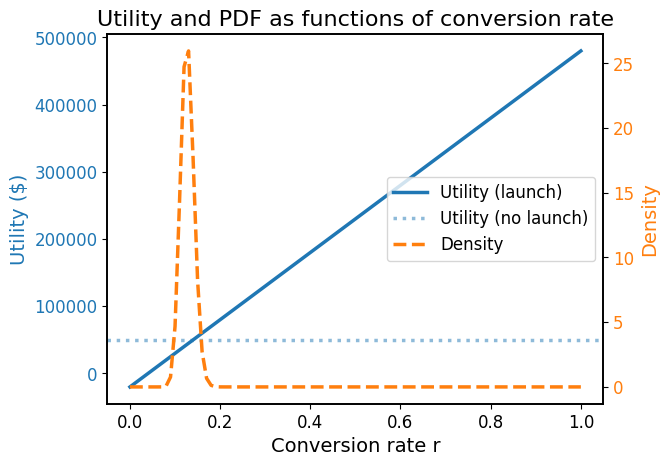

In [10]:
utility_color = "tab:blue"
posterior_color = "tab:orange"

fig, ax1 = plt.subplots()

ax1.plot(r_grid, launch_utility_grid, color=utility_color, label="Utility (launch)")
ax1.axhline(no_launch_utility_grid[0], linestyle=':', color=utility_color, alpha=0.5, label="Utility (no launch)")
ax1.set_xlabel("Conversion rate r")
ax1.set_ylabel("Utility ($)", color=utility_color)
ax1.tick_params(axis='y', labelcolor=utility_color)

# Posterior axis (right)
ax2 = ax1.twinx()
ax2.plot(r_grid, posterior_pdf, linestyle='--', color=posterior_color, label="Density")
ax2.set_ylabel("Density", color=posterior_color)
ax2.tick_params(axis='y', labelcolor=posterior_color)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

plt.title("Utility and PDF as functions of conversion rate")
plt.show()

In [11]:
n_samples = 100_000

np.random.seed(0)
r_samples = np.random.beta(a + k, b + n - k, size=n_samples)

In [12]:
launch_utility_samples = utility_launch(r_samples)
no_launch_utility_samples = utility_no_launch(r_samples)

launch_expected_utility = launch_utility_samples.mean()
no_launch_expected_utility = no_launch_utility_samples.mean()

(
    launch_expected_utility,
    no_launch_expected_utility,
    launch_expected_utility - no_launch_expected_utility
)

(43748.11945793371, 50000.0, -6251.88054206629)

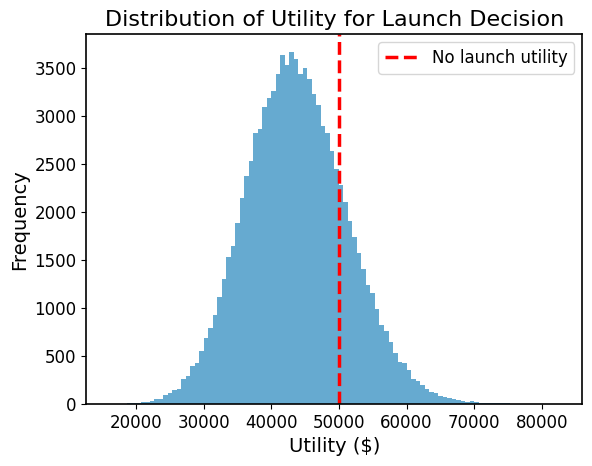

In [13]:
# Plot distribution of utility
plt.hist(launch_utility_samples, bins=100, alpha=0.6)
plt.axvline(no_launch_utility_grid[0], linestyle='--', c="r", label="No launch utility")
plt.title("Distribution of Utility for Launch Decision")
plt.legend()
plt.xlabel("Utility ($)")
plt.ylabel("Frequency")
plt.show()